# Outlier Detection Using Percentiles

### What is a Percentile?
A percentile tells you **what percentage of data falls below a certain value**.

```
1st  percentile (0.01) → 1% of data is below this value
99th percentile (0.99) → 99% of data is below this value
50th percentile (0.50) → 50% of data is below this value (median)
```

### How it detects outliers:
```
Values below 1st percentile  → unusually LOW  → outlier
Values above 99th percentile → unusually HIGH → outlier
```

### Percentile vs Z-Score:
```
Z-Score     → uses mean and std → sensitive to outliers themselves
Percentile  → uses rank position → more robust, works on any distribution
```
Percentile method is better when data is **skewed** or **not normally distributed**.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the weight-height dataset
# Contains Gender, Height and Weight of 10,000 people
df = pd.read_csv('weight-height.csv')

In [3]:
# Preview first 5 rows
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
# Check shape — how many rows and columns
df.shape

(10000, 3)

In [5]:
# Check basic statistics of Height column
# mean, std, min, max, percentiles
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

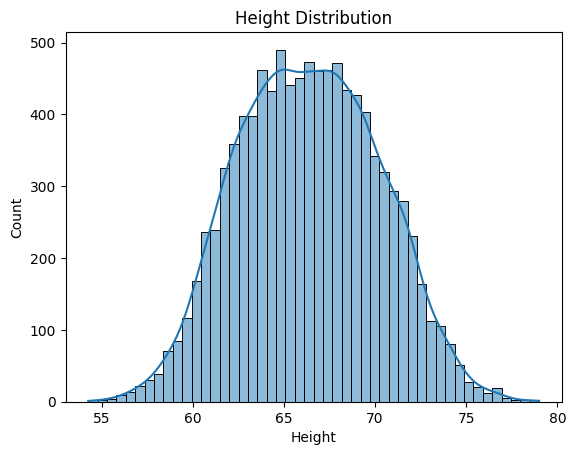

In [6]:
# Plot distribution of Height
# Check if it looks like a normal bell curve or skewed
sns.histplot(df['Height'], kde=True)
plt.title('Height Distribution')
plt.show()

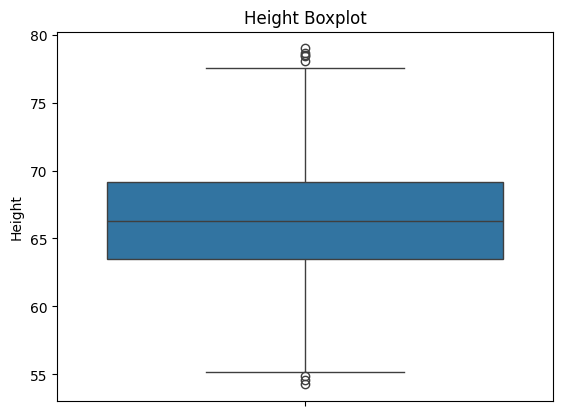

In [7]:
# Boxplot of Height
# The dots outside the whiskers are potential outliers
# Whiskers typically extend to 1.5 * IQR from the box
sns.boxplot(df['Height'])
plt.title('Height Boxplot')
plt.show()

## Step 1 — Find the Boundaries using Percentiles

In [8]:
# Calculate upper boundary — 99th percentile
# Any height above this value is in the top 1% → outlier
upper_limit = df['Height'].quantile(0.99)
print("Upper limit (99th percentile):", upper_limit)

Upper limit (99th percentile): 74.7857900583366


In [9]:
# Calculate lower boundary — 1st percentile
# Any height below this value is in the bottom 1% → outlier
lower_limit = df['Height'].quantile(0.01)
print("Lower limit (1st percentile):", lower_limit)

Lower limit (1st percentile): 58.13441158671655


In [10]:
# Find all outlier rows — heights outside the boundaries
outliers = df[(df['Height'] > upper_limit) | (df['Height'] < lower_limit)]
print(f"Number of outliers found: {len(outliers)}")
outliers.head()

Number of outliers found: 200


,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403


## Approach 1 — Trimming (remove outlier rows)

In [11]:
# Keep only rows where Height is within the percentile boundaries
# Rows with outlier heights are completely removed
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

print("Original shape:", df.shape)
print("After trimming: ", new_df.shape)
print(f"Rows removed:   {df.shape[0] - new_df.shape[0]}")

Original shape: (10000, 3)
After trimming:  (9800, 3)
Rows removed:   200


In [12]:
# Compare stats before and after trimming
print("Before trimming:")
print(df['Height'].describe())
print("\nAfter trimming:")
print(new_df['Height'].describe())

Before trimming:
count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

After trimming:
count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64


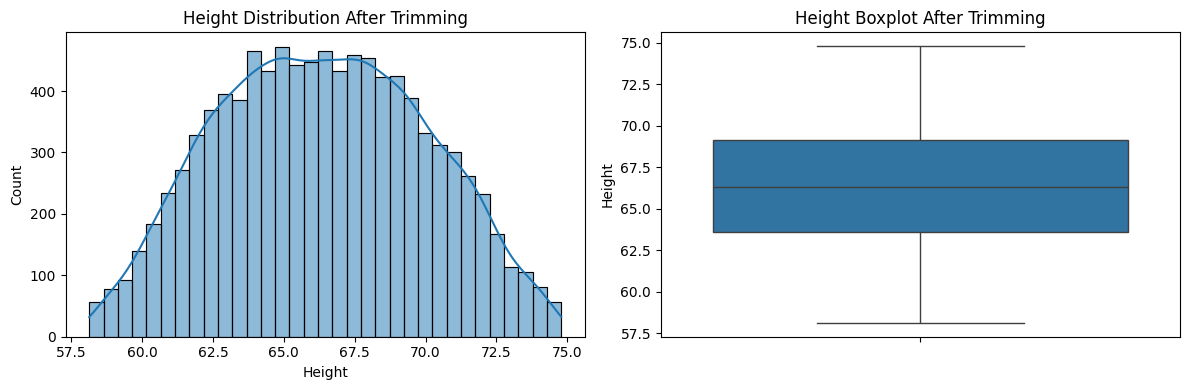

In [13]:
# Plot distribution after trimming
# Should look cleaner — extreme values removed
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(new_df['Height'], kde=True)
plt.title('Height Distribution After Trimming')

plt.subplot(1, 2, 2)
sns.boxplot(new_df['Height'])
plt.title('Height Boxplot After Trimming')

plt.tight_layout()
plt.show()

## Approach 2 — Capping / Winsorization (replace outliers with boundary values)

**Winsorization** is the technical name for capping.
Instead of deleting outlier rows, we **cap** them at the boundary value.

```
Trimming:      height = 80 (outlier) → ROW DELETED
Winsorization: height = 80 (outlier) → replaced with 74.78 (upper limit)
```

Advantage: **no data loss** — all rows are kept.

In [14]:
# Apply capping using np.where
# if height > upper_limit → replace with upper_limit
# elif height < lower_limit → replace with lower_limit
# else → keep original value

df['Height'] = np.where(
    df['Height'] >= upper_limit,
    upper_limit,              # cap high outliers at upper limit
    np.where(
        df['Height'] <= lower_limit,
        lower_limit,          # cap low outliers at lower limit
        df['Height']          # keep original if within range
    )
)

In [15]:
# Shape stays the same — no rows were deleted
print("Shape after capping:", df.shape)

Shape after capping: (10000, 3)


In [16]:
# Check stats after capping
# Max should now equal upper_limit
# Min should now equal lower_limit
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

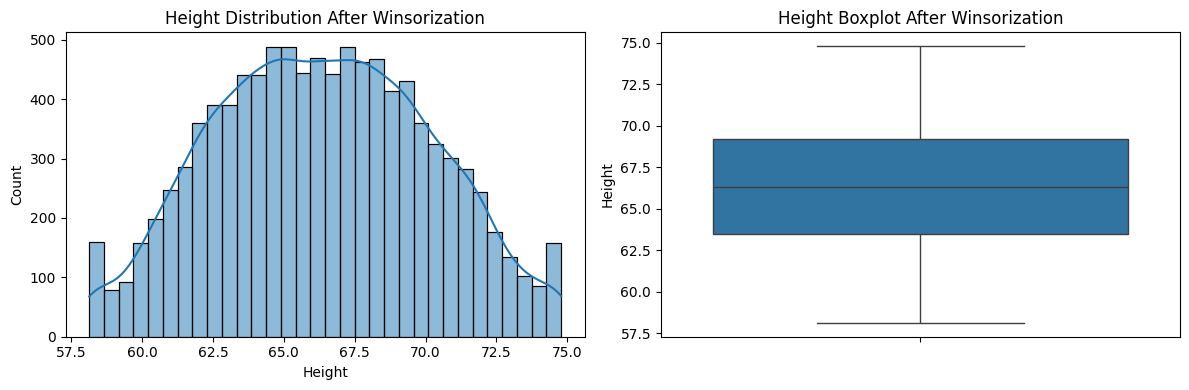

In [17]:
# Plot distribution after capping/winsorization
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Height'], kde=True)
plt.title('Height Distribution After Winsorization')

plt.subplot(1, 2, 2)
sns.boxplot(df['Height'])
plt.title('Height Boxplot After Winsorization')

plt.tight_layout()
plt.show()

## Summary

### Percentile boundaries used:
```
Lower boundary = 1st  percentile → bottom 1% are outliers
Upper boundary = 99th percentile → top 1% are outliers
```

You can adjust these thresholds:
```python
quantile(0.01) and quantile(0.99)  # remove top and bottom 1%  (default)
quantile(0.05) and quantile(0.95)  # remove top and bottom 5%  (more aggressive)
quantile(0.10) and quantile(0.90)  # remove top and bottom 10% (very aggressive)
```

### Trimming vs Capping:

| Method | What it does | Data Loss? | Also called |
|---|---|---|---|
| **Trimming** | removes outlier rows | Yes | Truncation |
| **Capping** | replaces outlier values with boundary | No | Winsorization |

### When to use Percentile over Z-Score?
- Data is **skewed** (not a normal distribution)
- Data has **extreme outliers** that could distort mean and std
- You want a **simpler, more intuitive** threshold